<a href="https://colab.research.google.com/github/achanltgd617-design/proteomics-plots/blob/main/ABL2_Proteomic_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Setup and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from google.colab import files

# Set some nice plotting defaults
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
sns.set_style('white')

print("Environment ready.")


Environment ready.


In [ ]:
# Cell 2: Upload the Excel file
uploaded = files.upload()
# A file picker will appear. Select all_comparison_result.xlsx.


Saving all_comparison_result.xlsx to all_comparison_result.xlsx


In [ ]:
# Cell 3: Read the data
df = pd.read_excel('all_comparison_result.xlsx', sheet_name=0)
print(f"Loaded {len(df)} rows.")
print(f"Columns: {df.columns.tolist()}")
df.head()


Loaded 13366 rows.
Columns: ['Protein', 'Label', 'log2FC', 'SE', 'Tvalue', 'DF', 'pvalue', 'adj.pvalue', 'issue', 'MissingPercentage', 'ImputationPercentage']


,Protein,Label,log2FC,SE,Tvalue,DF,pvalue,adj.pvalue,issue,MissingPercentage,ImputationPercentage
0,sp|Q3TEA8|HP1B3_MOUSE,Abl2_vs_ctrl,-0.330399,0.015030,-21.982347,9,3.939257e-09,0.000007,NaN,0.262500,0.262500
1,sp|Q9CQ86|MIEN1_MOUSE,Abl2_vs_ctrl,-0.445745,0.019497,-22.862255,9,2.782685e-09,0.000007,NaN,0.125000,0.125000
2,sp|Q9JIW9|RALB_MOUSE,Abl2_vs_ctrl,-0.584382,0.027021,-21.626552,9,4.551114e-09,0.000007,NaN,0.000000,0.000000
3,sp|P26645|MARCS_MOUSE,Abl2_vs_Abl1,-0.584572,0.025738,-22.712199,9,2.949879e-09,0.000007,NaN,0.221154,0.221154
4,sp|Q3TEA8|HP1B3_MOUSE,Abl2_vs_Abl1,-0.322255,0.015030,-21.440530,9,4.912459e-09,0.000007,NaN,0.262500,0.262500


In [ ]:
# Cell 4: Clean and parse the data
def extract_gene_symbol(protein_id):
    """
    Pull the gene symbol out of a UniProt ID like sp|Q3TEA8|HP1B3_MOUSE.
    Returns 'HP1B3' in this example. Strips the _MOUSE / _HUMAN suffix.
    """
    if pd.isna(protein_id):
        return None
    parts = str(protein_id).split('|')
    if len(parts) >= 3:
        symbol_with_species = parts[2]
        # Remove _MOUSE, _HUMAN, etc.
        symbol = re.sub(r'_(MOUSE|HUMAN|RAT|AEQVI|BOVIN|PIG)$', '', symbol_with_species)
        return symbol
    return protein_id  # fallback

def extract_uniprot_id(protein_id):
    """Pull the UniProt accession (e.g., Q3TEA8) for use with databases."""
    if pd.isna(protein_id):
        return None
    parts = str(protein_id).split('|')
    if len(parts) >= 2:
        return parts[1]
    return None

df['Gene'] = df['Protein'].apply(extract_gene_symbol)
df['UniProt'] = df['Protein'].apply(extract_uniprot_id)
df['is_contaminant'] = df['Protein'].astype(str).str.startswith('contam')

# Add a "significant" flag — conventional thresholds
df['significant'] = (df['adj.pvalue'] < 0.05) & (df['log2FC'].abs() > 0.25)
df['direction'] = np.where(df['log2FC'] > 0, 'up', 'down')

# Quick summary
print("Rows by contrast:")
print(df['Label'].value_counts())
print(f"\nContaminants: {df['is_contaminant'].sum()}")
print(f"\nSignificant hits per contrast (adj.p<0.05 & |log2FC|>0.25):")
print(df[df['significant']].groupby(['Label', 'direction']).size())


Rows by contrast:
Label
Abl1_vs_ctrl    4571
Abl2_vs_Abl1    4415
Abl2_vs_ctrl    4380
Name: count, dtype: int64

Contaminants: 49

Significant hits per contrast (adj.p<0.05 & |log2FC|>0.25):
Label         direction
Abl1_vs_ctrl  down          13
              up            44
Abl2_vs_Abl1  down         292
              up            21
Abl2_vs_ctrl  down         370
              up            82
dtype: int64


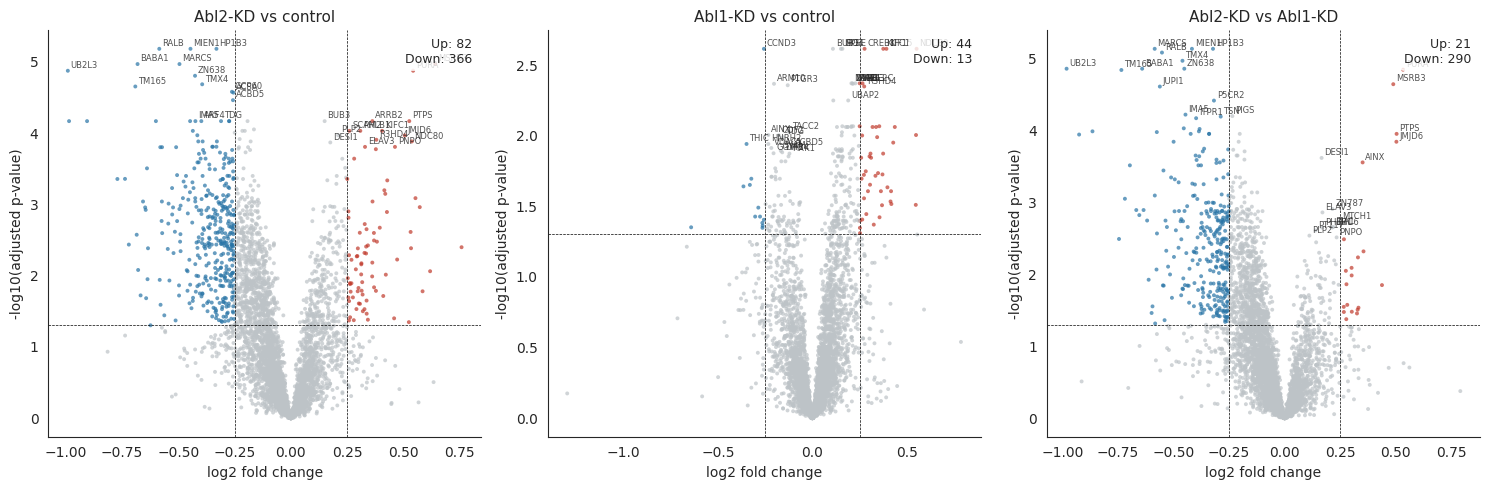

Saved Fig1_volcanoes.png and .pdf


In [ ]:
# Cell 5: Volcano plots for all three contrasts

def make_volcano(df_subset, title, ax, label_top_n=15):
    """
    Draw a volcano plot.
    x = log2FC, y = -log10(adj.pvalue).
    Color significant points; label the most extreme.
    """
    # Filter contaminants
    d = df_subset[~df_subset['is_contaminant']].copy()
    d = d.dropna(subset=['log2FC', 'adj.pvalue'])
    d['neg_log10_p'] = -np.log10(d['adj.pvalue'])

    # Color scheme: grey for non-sig, blue for down-sig, red for up-sig
    colors = np.where(
        d['significant'] & (d['log2FC'] > 0), '#C0392B',  # up = red
        np.where(d['significant'] & (d['log2FC'] < 0), '#2874A6',  # down = blue
                 '#BDC3C7')  # ns = grey
    )

    ax.scatter(d['log2FC'], d['neg_log10_p'], c=colors, s=8, alpha=0.7,
               edgecolors='none')

    # Threshold lines
    ax.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=0.5)
    ax.axvline(0.25, color='black', linestyle='--', linewidth=0.5)
    ax.axvline(-0.25, color='black', linestyle='--', linewidth=0.5)

    # Label top hits — most significant in each direction
    top_up = d[d['log2FC'] > 0].nlargest(label_top_n, 'neg_log10_p')
    top_down = d[d['log2FC'] < 0].nlargest(label_top_n, 'neg_log10_p')
    for _, row in pd.concat([top_up, top_down]).iterrows():
        ax.annotate(row['Gene'], xy=(row['log2FC'], row['neg_log10_p']),
                    fontsize=6, alpha=0.8,
                    xytext=(2, 2), textcoords='offset points')

    ax.set_xlabel('log2 fold change')
    ax.set_ylabel('-log10(adjusted p-value)')
    ax.set_title(title, fontsize=11)

    # Count and annotate
    n_up = ((d['significant']) & (d['log2FC'] > 0)).sum()
    n_down = ((d['significant']) & (d['log2FC'] < 0)).sum()
    ax.text(0.98, 0.98, f'Up: {n_up}\nDown: {n_down}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    sns.despine(ax=ax)

# Make the three-panel figure
contrasts = ['Abl2_vs_ctrl', 'Abl1_vs_ctrl', 'Abl2_vs_Abl1']
titles = ['Abl2-KD vs control', 'Abl1-KD vs control', 'Abl2-KD vs Abl1-KD']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, contrast, title in zip(axes, contrasts, titles):
    subset = df[df['Label'] == contrast]
    make_volcano(subset, title, ax)

plt.tight_layout()
plt.savefig('Fig1_volcanoes.png', dpi=300, bbox_inches='tight')
plt.savefig('Fig1_volcanoes.pdf', bbox_inches='tight')
plt.show()
print("Saved Fig1_volcanoes.png and .pdf")


In [ ]:
files.download('Fig1_volcanoes.png')
files.download('Fig1_volcanoes.pdf')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

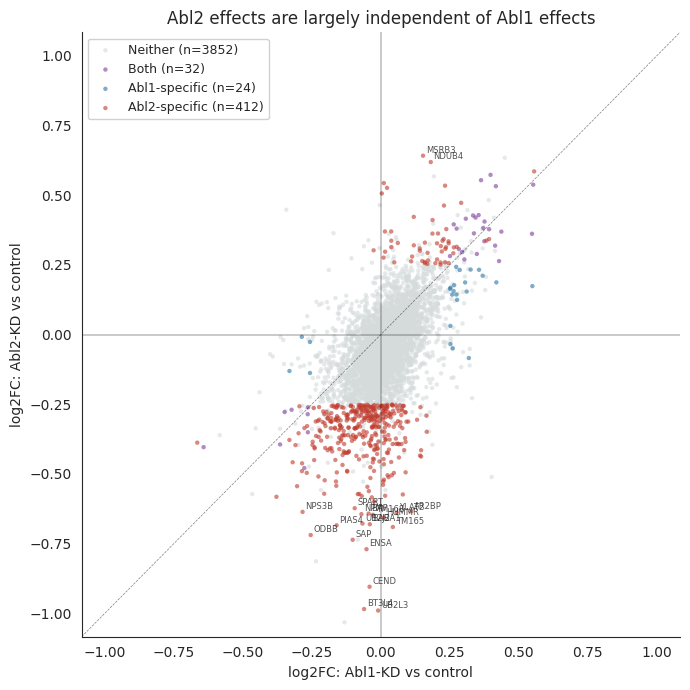


Specificity summary:
category
Neither          3852
Abl2-specific     412
Both               32
Abl1-specific      24
Name: count, dtype: int64


In [ ]:
# Cell 6 (corrected): Specificity scatter — Abl2 effect vs Abl1 effect

# Pivot the data so each protein has one row per contrast
pivot_lfc = df[~df['is_contaminant']].pivot_table(
    index='Gene', columns='Label', values='log2FC', aggfunc='first'
)
pivot_padj = df[~df['is_contaminant']].pivot_table(
    index='Gene', columns='Label', values='adj.pvalue', aggfunc='first'
)

# Keep proteins measured in both Abl2_vs_ctrl and Abl1_vs_ctrl (log2FC available in both)
both = pivot_lfc.dropna(subset=['Abl2_vs_ctrl', 'Abl1_vs_ctrl']).copy()

# Safely pull p-values, filling with NaN where absent
both['Abl2_padj'] = pivot_padj['Abl2_vs_ctrl'].reindex(both.index)
both['Abl1_padj'] = pivot_padj['Abl1_vs_ctrl'].reindex(both.index)

# Categorize (treat missing p-values as non-significant)
def categorize(row):
    abl2_sig = (pd.notna(row['Abl2_padj']) and row['Abl2_padj'] < 0.05
                and abs(row['Abl2_vs_ctrl']) > 0.25)
    abl1_sig = (pd.notna(row['Abl1_padj']) and row['Abl1_padj'] < 0.05
                and abs(row['Abl1_vs_ctrl']) > 0.25)
    if abl2_sig and not abl1_sig:
        return 'Abl2-specific'
    elif abl1_sig and not abl2_sig:
        return 'Abl1-specific'
    elif abl2_sig and abl1_sig:
        return 'Both'
    else:
        return 'Neither'

both['category'] = both.apply(categorize, axis=1)

# Plot
fig, ax = plt.subplots(figsize=(7, 7))
palette = {
    'Abl2-specific': '#C0392B',
    'Abl1-specific': '#2874A6',
    'Both': '#7D3C98',
    'Neither': '#D5DBDB'
}
for cat in ['Neither', 'Both', 'Abl1-specific', 'Abl2-specific']:
    d = both[both['category'] == cat]
    ax.scatter(d['Abl1_vs_ctrl'], d['Abl2_vs_ctrl'],
               c=palette[cat], s=10, alpha=0.6,
               label=f'{cat} (n={len(d)})', edgecolors='none')

lim = max(both['Abl1_vs_ctrl'].abs().max(),
          both['Abl2_vs_ctrl'].abs().max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.5, alpha=0.5)
ax.axhline(0, color='black', linewidth=0.3)
ax.axvline(0, color='black', linewidth=0.3)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('log2FC: Abl1-KD vs control')
ax.set_ylabel('log2FC: Abl2-KD vs control')
ax.set_title('Abl2 effects are largely independent of Abl1 effects')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
sns.despine(ax=ax)

# Label the most extreme Abl2-specific hits
top_abl2_specific = (both[both['category'] == 'Abl2-specific']
                     .assign(extremeness=lambda x: x['Abl2_vs_ctrl'].abs())
                     .nlargest(20, 'extremeness'))
for gene, row in top_abl2_specific.iterrows():
    ax.annotate(gene, xy=(row['Abl1_vs_ctrl'], row['Abl2_vs_ctrl']),
                fontsize=6, alpha=0.8,
                xytext=(2, 2), textcoords='offset points')

plt.tight_layout()
plt.savefig('Fig2_specificity_scatter.png', dpi=300, bbox_inches='tight')
plt.savefig('Fig2_specificity_scatter.pdf', bbox_inches='tight')
plt.show()
print(f"\nSpecificity summary:")
print(both['category'].value_counts())


In [ ]:
files.download('Fig2_specificity_scatter.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Cell 7a: Install gseapy
!pip install gseapy --quiet
print("gseapy installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 5.4 MB/s eta 0:00:00
gseapy installed.


In [ ]:
# Cell 7b: Build the gene lists for enrichment

# Pull Abl2_vs_ctrl results from the original (non-pivoted) dataframe
abl2_results = df[(df['Label'] == 'Abl2_vs_ctrl') &
                  (~df['is_contaminant']) &
                  (df['Gene'].notna())].copy()

# Significant Abl2-specific hits — using the categorization from Cell 6
abl2_specific_genes = both[both['category'] == 'Abl2-specific'].index.tolist()

# Split into up and down based on Abl2_vs_ctrl log2FC
abl2_specific_df = both.loc[abl2_specific_genes].copy()
genes_down = abl2_specific_df[abl2_specific_df['Abl2_vs_ctrl'] < 0].index.tolist()
genes_up = abl2_specific_df[abl2_specific_df['Abl2_vs_ctrl'] > 0].index.tolist()

# Background = all proteins measured in the Abl2 vs ctrl contrast
background = abl2_results['Gene'].dropna().unique().tolist()

print(f"Abl2-specific DOWN: {len(genes_down)} genes")
print(f"Abl2-specific UP:   {len(genes_up)} genes")
print(f"Background (all measured proteins): {len(background)} genes")
print(f"\nFirst 10 down-regulated genes: {genes_down[:10]}")
print(f"First 10 up-regulated genes:   {genes_up[:10]}")


Abl2-specific DOWN: 357 genes
Abl2-specific UP:   55 genes
Background (all measured proteins): 4364 genes

First 10 down-regulated genes: ['1433T', '2A5B', '5NT3A', '6PGD', 'ABHD6', 'ACBD5', 'ACBP', 'ACDSB', 'ACLY', 'ACOX1']
First 10 up-regulated genes:   ['A1AT2', 'APOA1', 'ARH40', 'ARP5', 'ARRB2', 'BRAT1', 'CARM1', 'CCNB1', 'CHIO', 'CK098']


In [ ]:
# Cell 7c (fixed): Run enrichment one library at a time, no background
import gseapy as gp
import time

libraries = [
    'GO_Biological_Process_2023',
    'GO_Cellular_Component_2023',
    'GO_Molecular_Function_2023',
    'KEGG_2019_Mouse',
    'Reactome_2022',
    'WikiPathways_2024_Mouse',
]

all_down_results = []
print("Running enrichment for DOWN-regulated proteins, library by library...")

for lib in libraries:
    print(f"  Querying {lib}...", end=' ')
    try:
        result = gp.enrichr(
            gene_list=genes_down,
            gene_sets=lib,
            organism='mouse',
            outdir=None,
            cutoff=1.0,  # keep all results, filter later
        )
        all_down_results.append(result.results)
        print(f"got {len(result.results)} terms.")
        time.sleep(2)  # be polite to the server
    except Exception as e:
        print(f"failed ({type(e).__name__}). Retrying once...")
        time.sleep(5)
        try:
            result = gp.enrichr(
                gene_list=genes_down,
                gene_sets=lib,
                organism='mouse',
                outdir=None,
                cutoff=1.0,
            )
            all_down_results.append(result.results)
            print(f"  retry succeeded: {len(result.results)} terms.")
        except Exception as e2:
            print(f"  retry also failed: {e2}. Skipping {lib}.")

# Combine all results
enr_down_df = pd.concat(all_down_results, ignore_index=True)
print(f"\nTotal enriched terms across all libraries: {len(enr_down_df)}")
print(f"Terms with adj.p < 0.05: {(enr_down_df['Adjusted P-value'] < 0.05).sum()}")

print(f"\nTop 25 enriched pathways (DOWN in Abl2-KD):")
top_down = enr_down_df.sort_values('Adjusted P-value').head(25)
print(top_down[['Gene_set', 'Term', 'Overlap', 'Adjusted P-value']].to_string())


Running enrichment for DOWN-regulated proteins, library by library...
  Querying GO_Biological_Process_2023... got 1087 terms.
  Querying GO_Cellular_Component_2023... got 169 terms.
  Querying GO_Molecular_Function_2023... got 225 terms.
  Querying KEGG_2019_Mouse... got 172 terms.
  Querying Reactome_2022... got 570 terms.
  Querying WikiPathways_2024_Mouse... got 62 terms.

Total enriched terms across all libraries: 2285
Terms with adj.p < 0.05: 3

Top 25 enriched pathways (DOWN in Abl2-KD):
                        Gene_set                                                                       Term Overlap  Adjusted P-value
2223     WikiPathways_2024_Mouse                                Omega 3 Omega 6 Fatty Acid Synthesis WP4350    3/15          0.047578
2224     WikiPathways_2024_Mouse                                             Cholesterol Biosynthesis WP103    3/15          0.047578
2225     WikiPathways_2024_Mouse       Cholesterol Metabolism W Bloch And Kandutsch Russell Pathwa

In [ ]:
# Cell 7d (fixed): Same approach for UP-regulated proteins
all_up_results = []
print("Running enrichment for UP-regulated proteins, library by library...")

for lib in libraries:
    print(f"  Querying {lib}...", end=' ')
    try:
        result = gp.enrichr(
            gene_list=genes_up,
            gene_sets=lib,
            organism='mouse',
            outdir=None,
            cutoff=1.0,
        )
        all_up_results.append(result.results)
        print(f"got {len(result.results)} terms.")
        time.sleep(2)
    except Exception as e:
        print(f"failed ({type(e).__name__}). Retrying...")
        time.sleep(5)
        try:
            result = gp.enrichr(
                gene_list=genes_up,
                gene_sets=lib,
                organism='mouse',
                outdir=None,
                cutoff=1.0,
            )
            all_up_results.append(result.results)
            print(f"  retry succeeded: {len(result.results)} terms.")
        except Exception as e2:
            print(f"  retry also failed: {e2}. Skipping {lib}.")

enr_up_df = pd.concat(all_up_results, ignore_index=True)
print(f"\nTotal terms (up): {len(enr_up_df)}")
print(f"Terms with adj.p < 0.05 (up): {(enr_up_df['Adjusted P-value'] < 0.05).sum()}")

print(f"\nTop 15 enriched pathways (UP in Abl2-KD):")
top_up = enr_up_df.sort_values('Adjusted P-value').head(15)
print(top_up[['Gene_set', 'Term', 'Overlap', 'Adjusted P-value']].to_string())


Running enrichment for UP-regulated proteins, library by library...
  Querying GO_Biological_Process_2023... got 364 terms.
  Querying GO_Cellular_Component_2023... got 33 terms.
  Querying GO_Molecular_Function_2023... got 72 terms.
  Querying KEGG_2019_Mouse... got 40 terms.
  Querying Reactome_2022... got 275 terms.
  Querying WikiPathways_2024_Mouse... got 20 terms.

Total terms (up): 804
Terms with adj.p < 0.05 (up): 47

Top 15 enriched pathways (UP in Abl2-KD):
                    Gene_set                                                                                  Term Overlap  Adjusted P-value
509            Reactome_2022  TP53 Regulates Transcription Of Genes Involved In G2 Cell Cycle Arrest R-HSA-6804114    3/18          0.002984
510            Reactome_2022                                                 Phosphorylation Of APC/C R-HSA-176412    3/20          0.002984
784  WikiPathways_2024_Mouse                                                                Mismatch Repa

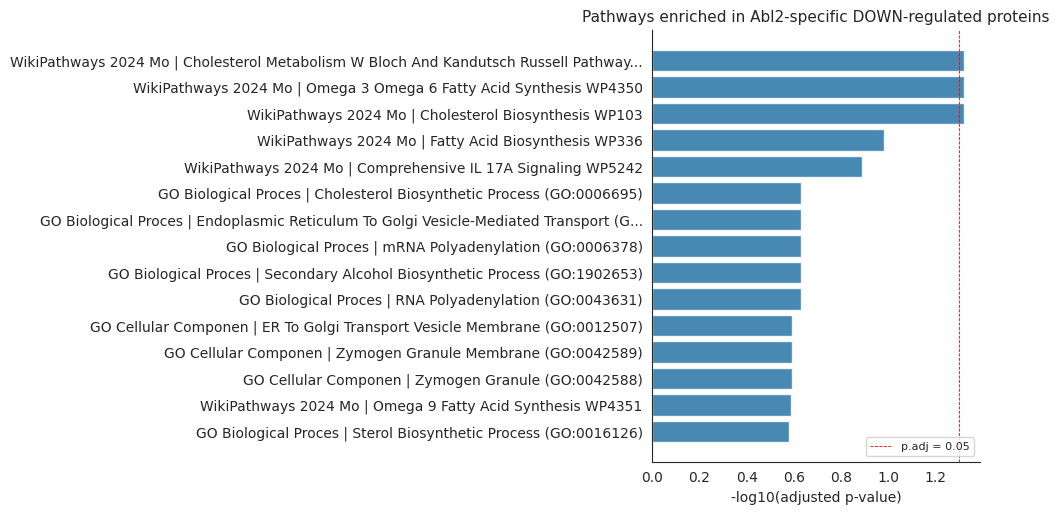

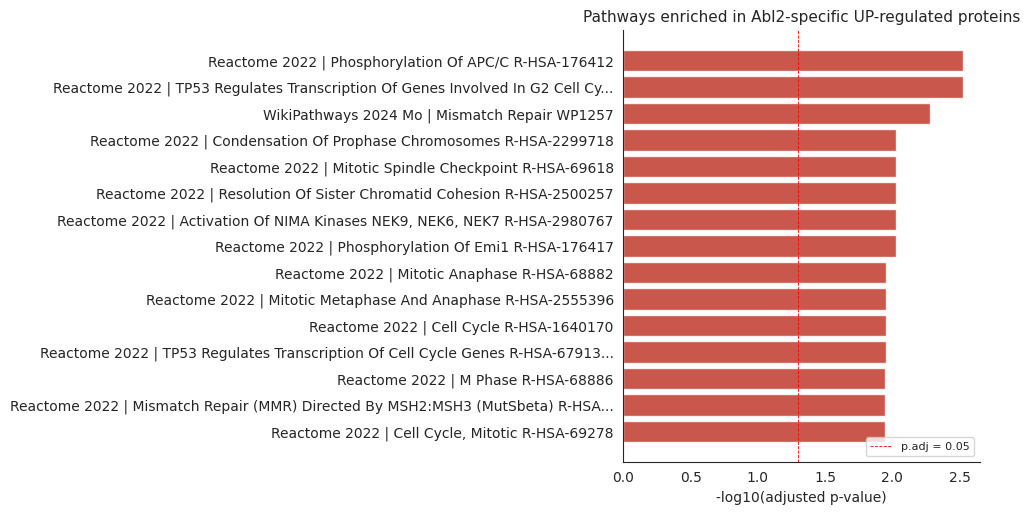

Saved enrichment figures.


In [ ]:
# Cell 7e (fixed): Plot top enriched pathways

def plot_enrichment_bars(enr_df, title, n=15, color='#2874A6'):
    top = enr_df.sort_values('Adjusted P-value').head(n).copy()
    top['neg_log10_padj'] = -np.log10(top['Adjusted P-value'])
    top['Term_short'] = top['Term'].apply(lambda x: x[:60] + '...' if len(x) > 60 else x)
    top['label'] = top['Gene_set'].str.replace('_', ' ').str[:20] + ' | ' + top['Term_short']

    fig, ax = plt.subplots(figsize=(10, max(5, n * 0.35)))
    top_sorted = top.sort_values('neg_log10_padj')
    ax.barh(top_sorted['label'], top_sorted['neg_log10_padj'], color=color, alpha=0.85)
    ax.set_xlabel('-log10(adjusted p-value)')
    ax.set_title(title, fontsize=11)
    ax.axvline(-np.log10(0.05), color='red', linestyle='--', linewidth=0.6,
               label='p.adj = 0.05')
    ax.legend(loc='lower right', fontsize=8)
    sns.despine(ax=ax)
    plt.tight_layout()
    return fig

plot_enrichment_bars(enr_down_df,
                     'Pathways enriched in Abl2-specific DOWN-regulated proteins',
                     n=15, color='#2874A6')
plt.savefig('Fig3a_enrichment_down.png', dpi=300, bbox_inches='tight')
plt.savefig('Fig3a_enrichment_down.pdf', bbox_inches='tight')
plt.show()

plot_enrichment_bars(enr_up_df,
                     'Pathways enriched in Abl2-specific UP-regulated proteins',
                     n=15, color='#C0392B')
plt.savefig('Fig3b_enrichment_up.png', dpi=300, bbox_inches='tight')
plt.savefig('Fig3b_enrichment_up.pdf', bbox_inches='tight')
plt.show()

print("Saved enrichment figures.")


In [ ]:
# Cell 7f (fixed): Save tables
enr_down_df.sort_values('Adjusted P-value').to_csv('TableS1_enrichment_DOWN.csv', index=False)
enr_up_df.sort_values('Adjusted P-value').to_csv('TableS2_enrichment_UP.csv', index=False)
print("Saved TableS1 and TableS2.")


Saved TableS1 and TableS2.


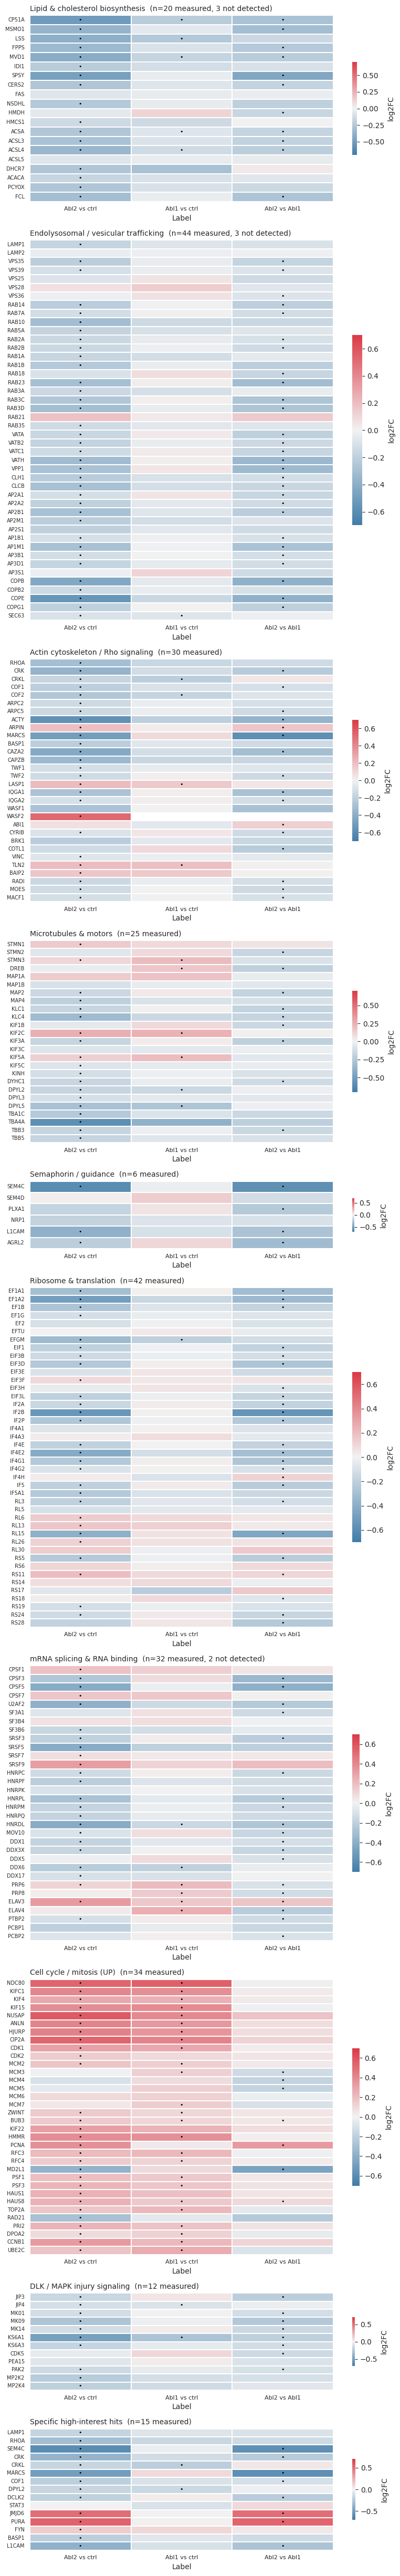


Saved Fig2_module_heatmap.png and .pdf


In [ ]:
# Cell 8b: Curated heatmap of functional modules in Abl2-KD

# Define modules — these are biologically motivated, based on Abl2 literature and your data
modules = {
    'Lipid & cholesterol biosynthesis': [
        'CP51A','MSMO1','LSS','FPPS','MVD1','IDI1','SPSY','SQLE','CERS2','FAS',
        'NSDHL','HMDH','HMCS1','ACSA','ACSL3','ACSL4','ACSL5','DHCR7','SCAP','SREB1',
        'ACACA','PCYOX','FCL'
    ],
    'Endolysosomal / vesicular trafficking': [
        'LAMP1','LAMP2','VPS35','VPS39','VPS25','VPS28','VPS36','RAB14','RAB7A','RAB10',
        'RAB5A','RAB2A','RAB2B','RAB1A','RAB1B','RAB18','RAB23','RAB3A','RAB3C','RAB3D',
        'RAB21','RAB35','VATA','VATB2','VATC1','VATH','VPP1','CLH1','CLCB','AP2A1',
        'AP2A2','AP2B1','AP2M1','AP2S1','AP1B1','AP1M1','AP3B1','AP3D1','AP3S1','COPB',
        'COPB2','COPE','COPG1','SEC23A','SEC61A1','SEC61G','SEC63'
    ],
    'Actin cytoskeleton / Rho signaling': [
        'RHOA','CRK','CRKL','COF1','COF2','ARPC2','ARPC5','ACTY','ARPIN','MARCS','BASP1',
        'CAZA2','CAPZB','TWF1','TWF2','LASP1','IQGA1','IQGA2','WASF1','WASF2','ABI1',
        'CYRIB','BRK1','COTL1','VINC','TLN2','BAIP2','RADI','MOES','MACF1'
    ],
    'Microtubules & motors': [
        'STMN1','STMN2','STMN3','DREB','MAP1A','MAP1B','MAP2','MAP4','KLC1','KLC4',
        'KIF1B','KIF2C','KIF3A','KIF3C','KIF5A','KIF5C','KINH','DYHC1','DPYL2','DPYL3',
        'DPYL5','TBA1C','TBA4A','TBB3','TBB5'
    ],
    'Semaphorin / guidance': [
        'SEM4C','SEM4D','PLXA1','NRP1','L1CAM','AGRL2'
    ],
    'Ribosome & translation': [
        'EF1A1','EF1A2','EF1B','EF1G','EF2','EFTU','EFGM','EIF1','EIF3B','EIF3D','EIF3E',
        'EIF3F','EIF3H','EIF3L','IF2A','IF2B','IF2P','IF4A1','IF4A3','IF4E','IF4E2',
        'IF4G1','IF4G2','IF4H','IF5','IF5A1','RL3','RL5','RL6','RL13','RL15','RL26',
        'RL30','RS5','RS6','RS11','RS14','RS17','RS18','RS19','RS24','RS28'
    ],
    'mRNA splicing & RNA binding': [
        'CPSF1','CPSF3','CPSF5','CPSF7','U2AF2','SF3A1','SF3B4','SF3B6','SRSF3','SRSF5',
        'SRSF7','SRSF9','HNRPC','HNRPF','HNRPK','HNRPL','HNRPM','HNRPQ','HNRDL','MOV10',
        'DDX1','DDX3X','DDX5','DDX6','DDX17','PRP6','PRP8','ELAV3','ELAV4','MSI1','MSI2',
        'PTBP2','PCBP1','PCBP2'
    ],
    'Cell cycle / mitosis (UP)': [
        'NDC80','KIFC1','KIF4','KIF15','NUSAP','ANLN','HJURP','CIP2A','CDK1','CDK2',
        'MCM2','MCM3','MCM4','MCM5','MCM6','MCM7','ZWINT','BUB3','KIF22','HMMR','PCNA',
        'RFC3','RFC4','MD2L1','PSF1','PSF3','HAUS1','HAUS8','TOP2A','RAD21','PRI2','DPOA2',
        'CCNB1','UBE2C'
    ],
    'DLK / MAPK injury signaling': [
        'JIP3','JIP4','MK01','MK09','MK14','KS6A1','KS6A3','CDK5','PEA15','PAK2','MP2K2','MP2K4'
    ],
    'Specific high-interest hits': [
        'LAMP1','RHOA','SEM4C','CRK','CRKL','MARCS','COF1','DPYL2','DCLK2','STAT3',
        'JMJD6','PURA','FYN','BASP1','L1CAM'
    ],
}

# Build the heatmap matrix: rows = genes, cols = contrasts
contrast_order = ['Abl2_vs_ctrl', 'Abl1_vs_ctrl', 'Abl2_vs_Abl1']
lfc_matrix = pivot_lfc[contrast_order]
padj_matrix = pivot_padj[contrast_order]

import matplotlib.colors as mcolors

# Plot module by module
n_modules = len(modules)
fig, axes = plt.subplots(n_modules, 1,
                          figsize=(8, sum(max(2, len(g)*0.18) for g in modules.values())),
                          gridspec_kw={'height_ratios':
                              [max(1.5, len(g)*0.18) for g in modules.values()]})
if n_modules == 1:
    axes = [axes]

cmap = sns.diverging_palette(240, 10, as_cmap=True)  # blue-white-red
vmax = 0.7
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

for ax, (mod_name, gene_list) in zip(axes, modules.items()):
    # Restrict to genes actually measured
    present = [g for g in gene_list if g in lfc_matrix.index]
    missing = [g for g in gene_list if g not in lfc_matrix.index]
    sub = lfc_matrix.loc[present, contrast_order]

    # Annotate cells where adj.p < 0.05 with a dot
    annot_matrix = padj_matrix.loc[present, contrast_order]
    annot_text = annot_matrix.map(
        lambda p: '•' if pd.notna(p) and p < 0.05 else ''
    )

    sns.heatmap(sub, cmap=cmap, norm=norm, ax=ax,
                annot=annot_text, fmt='', annot_kws={'size': 8, 'color': 'black'},
                cbar=True, cbar_kws={'label': 'log2FC', 'shrink': 0.5},
                linewidths=0.3, linecolor='white',
                xticklabels=['Abl2 vs ctrl', 'Abl1 vs ctrl', 'Abl2 vs Abl1'],
                yticklabels=True)
    ax.set_title(f'{mod_name}  (n={len(present)} measured'
                 + (f', {len(missing)} not detected)' if missing else ')'),
                 fontsize=10, loc='left')
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=7)
    ax.tick_params(axis='x', labelsize=8, rotation=0)

plt.tight_layout()
plt.savefig('Fig2_module_heatmap.png', dpi=300, bbox_inches='tight')
plt.savefig('Fig2_module_heatmap.pdf', bbox_inches='tight')
plt.show()
print("\nSaved Fig2_module_heatmap.png and .pdf")


In [ ]:
# Cell 9: Custom Fisher's exact enrichment with proper background
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Universe = all proteins detected in the Abl2_vs_ctrl contrast (the background)
universe = set(background)
print(f"Universe size: {len(universe)} detected proteins")

# Hit lists from the specificity analysis (Cell 6)
hit_down = set(genes_down) & universe
hit_up = set(genes_up) & universe
print(f"Down hits in universe: {len(hit_down)}")
print(f"Up hits in universe:   {len(hit_up)}")

def fisher_enrichment(hit_set, module_genes, universe):
    """
    2x2 Fisher's exact test:
                    In hit    Not in hit
    In module       a         b
    Not in module   c         d
    """
    module_set = set(module_genes) & universe   # restrict module to detected proteins
    a = len(module_set & hit_set)
    b = len(module_set - hit_set)
    c = len(hit_set - module_set)
    d = len(universe - hit_set - module_set)
    if a == 0 or len(module_set) == 0:
        return {'k_module_detected': len(module_set), 'k_overlap': a,
                'odds_ratio': np.nan, 'pvalue': 1.0}
    odds, p = stats.fisher_exact([[a, b], [c, d]], alternative='greater')
    return {'k_module_detected': len(module_set),
            'k_overlap': a,
            'fraction_overlap': a / len(module_set) if len(module_set) > 0 else 0,
            'odds_ratio': odds,
            'pvalue': p,
            'overlapping_genes': sorted(module_set & hit_set)}

# Run for both directions
records = []
for direction, hit_set in [('down', hit_down), ('up', hit_up)]:
    for mod_name, mod_genes in modules.items():
        r = fisher_enrichment(hit_set, mod_genes, universe)
        r['module'] = mod_name
        r['direction'] = direction
        r['module_size_input'] = len(mod_genes)
        records.append(r)

enrich_df = pd.DataFrame(records)

# Multiple-testing correction across all tests
_, padj, _, _ = multipletests(enrich_df['pvalue'], method='fdr_bh')
enrich_df['padj_BH'] = padj
enrich_df['neg_log10_padj'] = -np.log10(enrich_df['padj_BH'].clip(lower=1e-300))

# Clean display
display_cols = ['module', 'direction', 'module_size_input', 'k_module_detected',
                'k_overlap', 'fraction_overlap', 'odds_ratio', 'pvalue', 'padj_BH']
print("\n=== Fisher's exact enrichment with proper background ===")
print(enrich_df.sort_values('padj_BH')[display_cols].to_string(index=False))

# Save the full table including overlapping genes
enrich_df_save = enrich_df.copy()
enrich_df_save['overlapping_genes'] = enrich_df_save['overlapping_genes'].apply(
    lambda x: '; '.join(x) if isinstance(x, list) else '')
enrich_df_save.sort_values('padj_BH').to_csv(
    'TableS3_custom_enrichment.csv', index=False)
print("\nSaved TableS3_custom_enrichment.csv")


Universe size: 4364 detected proteins
Down hits in universe: 357
Up hits in universe:   55

=== Fisher's exact enrichment with proper background ===
                               module direction  module_size_input  k_module_detected  k_overlap  fraction_overlap  odds_ratio       pvalue      padj_BH
     Lipid & cholesterol biosynthesis      down                 23                 20         13          0.650000   21.594684 2.727062e-10 5.454125e-09
Endolysosomal / vesicular trafficking      down                 47                 44         11          0.250000    3.828516 6.115415e-04 6.115415e-03
   Actin cytoskeleton / Rho signaling      down                 30                 30          8          0.266667    4.152123 2.181341e-03 1.454227e-02
          Specific high-interest hits      down                 15                 15          5          0.333333    5.677557 5.375920e-03 2.687960e-02
            Cell cycle / mitosis (UP)        up                 34                 34 

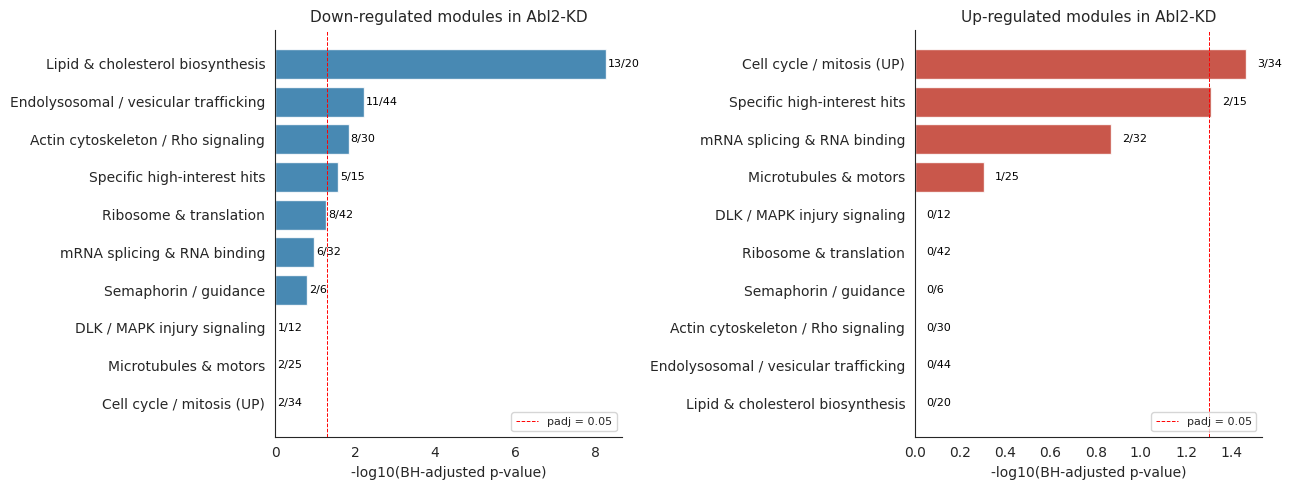

In [ ]:
# Cell 10: Plot custom enrichment results

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, direction, color in zip(axes, ['down', 'up'], ['#2874A6', '#C0392B']):
    d = enrich_df[enrich_df['direction'] == direction].copy()
    d = d.sort_values('neg_log10_padj', ascending=True)
    bars = ax.barh(d['module'], d['neg_log10_padj'], color=color, alpha=0.85)
    ax.axvline(-np.log10(0.05), color='red', linestyle='--', linewidth=0.7,
               label='padj = 0.05')
    ax.set_xlabel('-log10(BH-adjusted p-value)')
    ax.set_title(f'{"Down" if direction=="down" else "Up"}-regulated modules in Abl2-KD',
                 fontsize=11)
    # Annotate each bar with overlap fraction
    for bar, (_, row) in zip(bars, d.iterrows()):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f"{row['k_overlap']}/{row['k_module_detected']}",
                va='center', fontsize=8, color='black')
    ax.legend(loc='lower right', fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('Fig3_custom_enrichment.png', dpi=300, bbox_inches='tight')
plt.savefig('Fig3_custom_enrichment.pdf', bbox_inches='tight')
plt.show()


Genes detected per module:
  Lipid & cholesterol biosynthesis (padj=5e-9)        detected: 20/23
     missing: ['SQLE', 'SCAP', 'SREB1']
  Endolysosomal / vesicular trafficking (padj=0.006)  detected: 44/47
     missing: ['SEC23A', 'SEC61A1', 'SEC61G']
  Actin cytoskeleton / Rho signaling (padj=0.015)     detected: 30/30
  Cell cycle / mitosis (padj=0.034, UP)               detected: 34/34


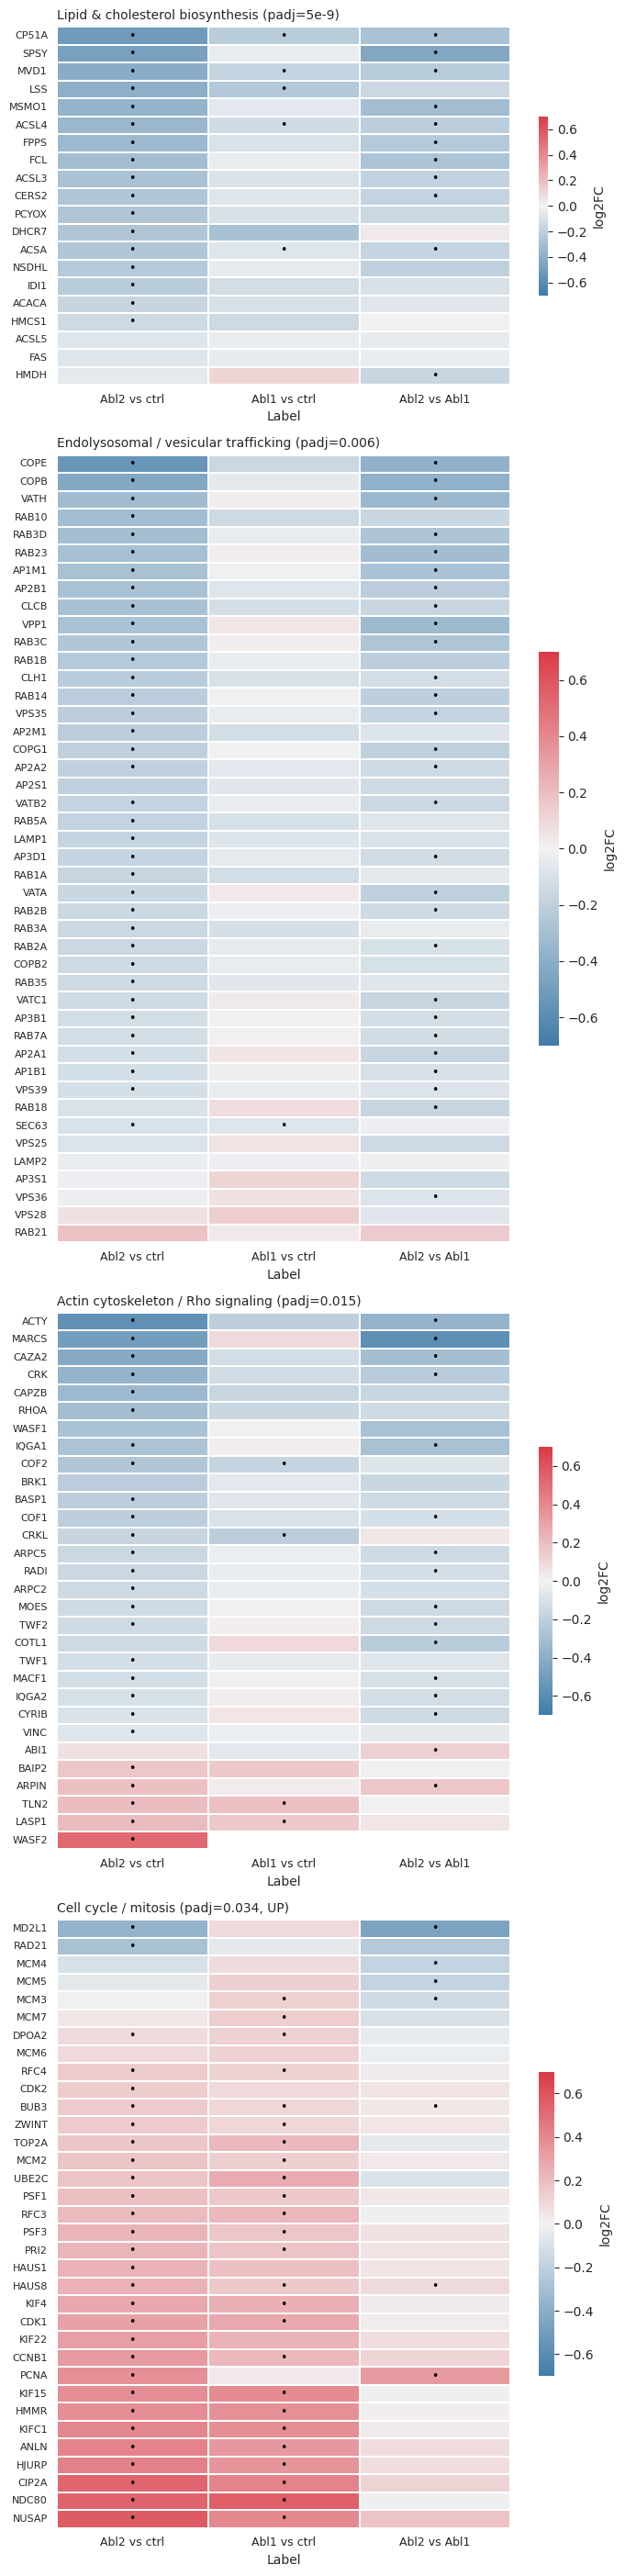

Done.


In [ ]:
# Cell 10 (clean rerun, compact): heatmap of statistically significant modules
import matplotlib.colors as mcolors

sig_modules = {
    'Lipid & cholesterol biosynthesis (padj=5e-9)': ['CP51A','MSMO1','LSS','FPPS','MVD1','IDI1','SPSY','SQLE','CERS2','FAS','NSDHL','HMDH','HMCS1','ACSA','ACSL3','ACSL4','ACSL5','DHCR7','SCAP','SREB1','ACACA','PCYOX','FCL'],
    'Endolysosomal / vesicular trafficking (padj=0.006)': ['LAMP1','LAMP2','VPS35','VPS39','VPS25','VPS28','VPS36','RAB14','RAB7A','RAB10','RAB5A','RAB2A','RAB2B','RAB1A','RAB1B','RAB18','RAB23','RAB3A','RAB3C','RAB3D','RAB21','RAB35','VATA','VATB2','VATC1','VATH','VPP1','CLH1','CLCB','AP2A1','AP2A2','AP2B1','AP2M1','AP2S1','AP1B1','AP1M1','AP3B1','AP3D1','AP3S1','COPB','COPB2','COPE','COPG1','SEC23A','SEC61A1','SEC61G','SEC63'],
    'Actin cytoskeleton / Rho signaling (padj=0.015)': ['RHOA','CRK','CRKL','COF1','COF2','ARPC2','ARPC5','ACTY','ARPIN','MARCS','BASP1','CAZA2','CAPZB','TWF1','TWF2','LASP1','IQGA1','IQGA2','WASF1','WASF2','ABI1','CYRIB','BRK1','COTL1','VINC','TLN2','BAIP2','RADI','MOES','MACF1'],
    'Cell cycle / mitosis (padj=0.034, UP)': ['NDC80','KIFC1','KIF4','KIF15','NUSAP','ANLN','HJURP','CIP2A','CDK1','CDK2','MCM2','MCM3','MCM4','MCM5','MCM6','MCM7','ZWINT','BUB3','KIF22','HMMR','PCNA','RFC3','RFC4','MD2L1','PSF1','PSF3','HAUS1','HAUS8','TOP2A','RAD21','PRI2','DPOA2','CCNB1','UBE2C'],
}

contrast_order = ['Abl2_vs_ctrl', 'Abl1_vs_ctrl', 'Abl2_vs_Abl1']
lfc_matrix = pivot_lfc[contrast_order]
padj_matrix = pivot_padj[contrast_order]

print("Genes detected per module:")
for mod_name, gene_list in sig_modules.items():
    present = [g for g in gene_list if g in lfc_matrix.index]
    missing = [g for g in gene_list if g not in lfc_matrix.index]
    print(f"  {mod_name[:50]:50s}  detected: {len(present)}/{len(gene_list)}")
    if missing:
        print(f"     missing: {missing}")

n_modules = len(sig_modules)
height_ratios = [max(2.0, len([g for g in genes if g in lfc_matrix.index]) * 0.22) for genes in sig_modules.values()]
fig, axes = plt.subplots(n_modules, 1, figsize=(7, sum(height_ratios)), gridspec_kw={'height_ratios': height_ratios})
if n_modules == 1:
    axes = [axes]

cmap = sns.diverging_palette(240, 10, as_cmap=True)
norm = mcolors.TwoSlopeNorm(vmin=-0.7, vcenter=0, vmax=0.7)

for ax, (mod_name, gene_list) in zip(axes, sig_modules.items()):
    present = [g for g in gene_list if g in lfc_matrix.index]
    if not present:
        ax.text(0.5, 0.5, 'No genes detected', ha='center', va='center')
        ax.set_title(mod_name, fontsize=10, loc='left')
        continue
    sub = lfc_matrix.loc[present, contrast_order].sort_values('Abl2_vs_ctrl')
    annot = padj_matrix.loc[sub.index, contrast_order].map(lambda p: '•' if pd.notna(p) and p < 0.05 else '')
    sns.heatmap(sub, cmap=cmap, norm=norm, ax=ax, annot=annot, fmt='',
                annot_kws={'size': 9, 'color': 'black'},
                cbar=True, cbar_kws={'label': 'log2FC', 'shrink': 0.5},
                linewidths=0.3, linecolor='white',
                xticklabels=['Abl2 vs ctrl', 'Abl1 vs ctrl', 'Abl2 vs Abl1'],
                yticklabels=True)
    ax.set_title(mod_name, fontsize=10, loc='left')
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=9, rotation=0)

plt.tight_layout()
plt.savefig('Fig2_significant_modules_heatmap.png', dpi=300, bbox_inches='tight')
plt.savefig('Fig2_significant_modules_heatmap.pdf', bbox_inches='tight')
plt.show()
print("Done.")
